# Question 6: Which country has produced the most successful tennis players? 

Using `event`, `home_team` and `away_team`

In [13]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
MINI_PROJECT_ROOT = Path.cwd().parents[2]

DATA_ROOT = (
    MINI_PROJECT_ROOT
    / "Tennis Schema"
    / "tennis_data"
)

PROCESSED_ROOT = DATA_ROOT / "processed"

TEAM_DATA_ROOT = DATA_ROOT / "Data"

In [3]:
match_event = pd.read_parquet(TEAM_DATA_ROOT / "event.parquet")
home_team = pd.read_parquet(TEAM_DATA_ROOT / "home_team.parquet")
away_team = pd.read_parquet(TEAM_DATA_ROOT / "away_team.parquet")

In [9]:
match_event = (match_event.sort_values("snapshot_date").drop_duplicates("match_id", keep="last"))
home_team = (home_team.sort_values("snapshot_date").drop_duplicates("match_id", keep="last"))
away_team = (away_team.sort_values("snapshot_date").drop_duplicates("match_id", keep="last"))

In [10]:
home_wins = match_event[match_event["winner_code"] == 1].merge(
    home_team[["match_id", "player_id", "country", "full_name"]], on="match_id", how="left")

away_wins = match_event[match_event["winner_code"] == 2].merge(
    away_team[["match_id", "player_id", "country", "full_name"]], on="match_id", how="left")

all_winners = pd.concat([
    home_wins[["player_id", "full_name", "country"]], away_wins[["player_id", "full_name", "country"]]])


In [11]:
country_wins = (all_winners.groupby("country").size().reset_index(name="wins").sort_values("wins", ascending=False))

country_wins.head()

,country,wins
30,France,1115
42,Italy,1069
88,USA,959
73,Russia,701
32,Germany,597


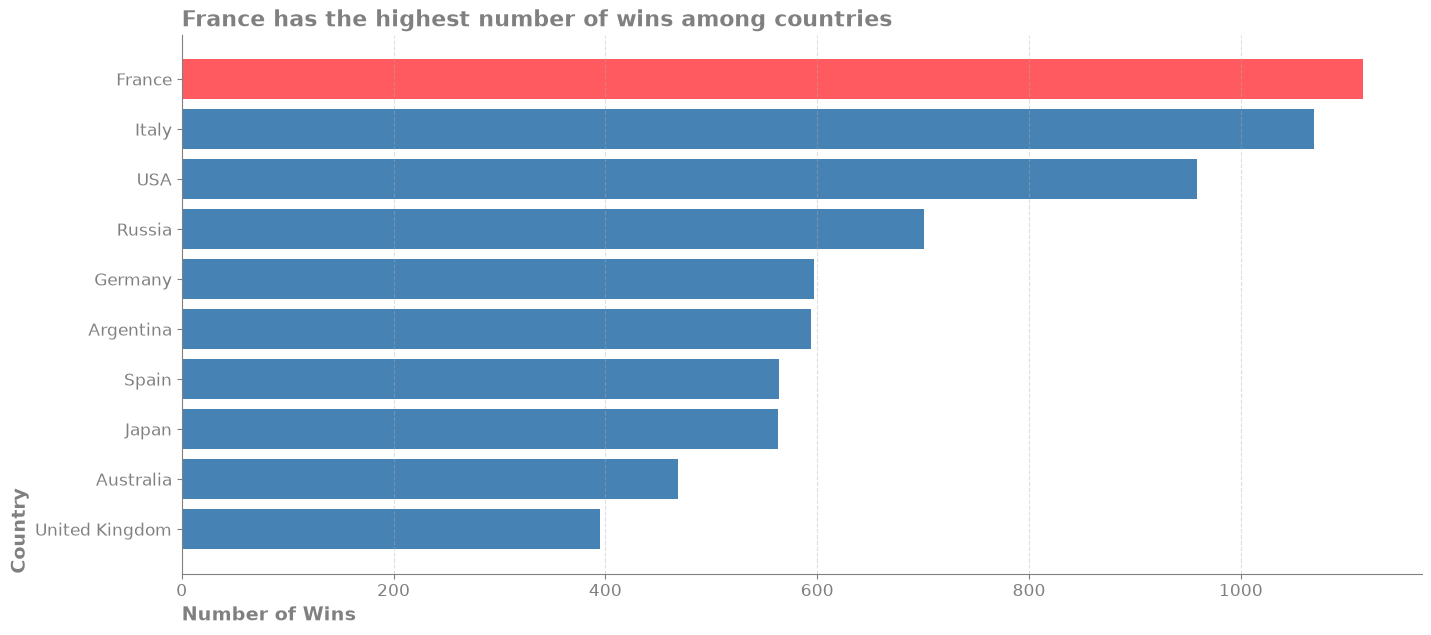

In [12]:
top_countries = country_wins.head(10).copy()

top_countries = top_countries.sort_values("wins", ascending=True)

top_countries["color"] = top_countries["country"].apply(
    lambda x: "#FF5A5F" if x == "France" else "#4682B4"
)

fig, ax = plt.subplots(figsize=(16, 7))

ax.barh(
    top_countries["country"],
    top_countries["wins"],
    color=top_countries["color"])

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title(
    "France has the highest number of wins among countries",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=16)

ax.set_xlabel(
    "Number of Wins",
    weight="bold",
    color="gray",
    loc="left",
    fontsize=14)

ax.set_ylabel(
    "Country",
    weight="bold",
    color="gray",
    loc="bottom",
    fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")
ax.grid(axis="x", linestyle="dashed", alpha=0.4)

plt.show()